# BridgeSAR example — Bay Bridge clearance from Sentinel-1 (P115, 2021–2023)

This notebook estimates the **bridge–water clearance** of the San Francisco–Oakland
Bay Bridge from OPERA CSLC-S1 amplitude images and compares the BridgeSAR
time-series against the on-bridge **NOAA air-gap sensor (station 9414304)**.

The amplitudes are **streamed live from NASA Earthdata** — the first run downloads
a few years of imagery and can take a while; products are cached on disk for
re-runs.

**Prerequisites**
- NASA Earthdata credentials in `~/.netrc` (see the README).
- `pip install bridgesar`


## 1. Configuration

Edit `DATA_DIR` to a folder where the streamed data and outputs should live.

In [1]:
from pathlib import Path
from bridgesar import BridgeConfig, ClearancePipeline
from bridgesar.osm import fetch_from_config
from bridgesar.stream import stream_amplitudes
from bridgesar.plotting import plot_clearance_timeseries

import warnings
warnings.filterwarnings("ignore")

DATA_DIR    = Path.cwd() / "BridgeSAR_data"   # where streamed data + outputs live
DATE_START  = "2021-01-01"
DATE_END    = "2023-12-31"
N_WORKERS   = 8                               # parallel workers (streaming + fitting)

cfg = BridgeConfig.named("baybridge_p115")
cfg.project_dir = str(DATA_DIR)
cfg.resolve_paths()
print("bridge :", cfg.bridge_name, cfg.track)
print("zarr   :", cfg.zarr_path)
print("air gap:", cfg.airgap_station)

bridge : Bay Bridge P115
zarr   : /Users/jinwook/Desktop/BridgeSAR/GitHub/examples/BridgeSAR_data/BayBridge/P115/OPERA_CSLC_S1_T115.zarr
air gap: 9414304


In [2]:
# Confirm Earthdata credentials are present before streaming.
import os
netrc = Path.home() / ".netrc"
assert netrc.exists(), "Create ~/.netrc with your NASA Earthdata credentials (see README)."
print("found ~/.netrc")


found ~/.netrc


## 2. Fetch the OpenStreetMap bridge centerline

In [3]:
gdf = fetch_from_config(cfg)
gdf[["osm_id", "name", "ref", "bridge", "highway"]]


wrote /Users/jinwook/Desktop/BridgeSAR/GitHub/examples/BridgeSAR_data/BayBridge/Inventory/osm_baybridge.geojson  (20 ways)


,osm_id,name,ref,bridge,highway
0,8921938,Dwight D. Eisenhower Highway,I 80,yes,motorway
1,23874736,Dwight D. Eisenhower Highway,I 80,yes,motorway
2,120813417,Route 80,I 80,yes,motorway
3,202485364,Route 80,I 80,yes,motorway
4,236348360,Dwight D. Eisenhower Highway,I 80,yes,motorway
5,236348361,Dwight D. Eisenhower Highway,I 80,yes,motorway
6,237731428,Dwight D. Eisenhower Highway,I 80,yes,motorway
7,394443187,Route 80,I 80,yes,motorway
8,394443189,Route 80,I 80,yes,motorway
9,497579295,Dwight D. Eisenhower Highway,I 80,yes,motorway


## 3. Stream amplitudes into an amplitude-only Zarr store

**Heavy step.** This streams every common-date Sentinel-1 P115 amplitude over the
Bay Bridge ROI into an amplitude-only Zarr store (with a progress bar). The
clearance pipeline reads amplitudes **directly from this Zarr** — no per-date
GeoTIFF export is needed. The store is cached, so re-running skips the download.

In [4]:
if not Path(cfg.zarr_path).exists():
    stream_amplitudes(cfg, DATE_START, DATE_END, n_workers=N_WORKERS)
else:
    print("zarr already exists — skipping stream:", cfg.zarr_path)
print("amplitude zarr ready:", cfg.zarr_path)

# Optional: export per-date GeoTIFFs for GIS inspection (not needed by the
# pipeline, which reads the Zarr directly).
# from bridgesar.amplitude import export_amplitudes_from_zarr
# export_amplitudes_from_zarr(cfg.zarr_path, cfg.amp_dir)

Track 115: 7251 total bursts, 1 overlap the ROI
  T115-245714-IW1: 92 granules
Found 92 CSLC granules total
Found static layers for 1/1 burst IDs
92 granules for Track 115, 1 unique burst IDs
92 dates with complete burst coverage
EPSG 32610, spacing 5 x -10 m
Pre-allocated amplitude-only zarr at /Users/jinwook/Desktop/BridgeSAR/GitHub/examples/BridgeSAR_data/BayBridge/P115/OPERA_CSLC_S1_T115.zarr (time=92, y=280, x=567)
Streaming 92 dates with 8 workers ...


Streaming amplitudes:   0%|          | 0/92 [00:00<?, ?date/s]

Wrote 92 dates to zarr; skipped 0
Finalized zarr metadata: 92 orbit records
Done streaming amplitudes.
amplitude zarr ready: /Users/jinwook/Desktop/BridgeSAR/GitHub/examples/BridgeSAR_data/BayBridge/P115/OPERA_CSLC_S1_T115.zarr


## 4. Run the clearance time-series

`setup()` loads the radar LOS geometry from the Zarr store, projects the OSM
centerline, and fits the global single-bounce stripe. `run_timeseries()` then
fits the S/D/T stripes per date and converts stripe spacing to clearance.

In [5]:
pipe = ClearancePipeline(cfg).setup()
df = pipe.run_timeseries(n_jobs=N_WORKERS)
kept = pipe.filter_timeseries(df)
print(f"processed {len(df)} dates; kept {len(kept)} after contrast/outlier filtering")
kept[["date_tag", "H_SD_m", "H_DT_m", "H_ST_m", "H_mean_m", "sigma_H_mean_m", "contrast_min"]].head()

processed 92 dates; kept 91 after contrast/outlier filtering


,date_tag,H_SD_m,H_DT_m,H_ST_m,H_mean_m,sigma_H_mean_m,contrast_min
0,20210109,61.518438,75.494881,59.506660,65.506660,0.182286,6.838387
1,20210121,61.437055,75.912757,59.674906,65.674906,0.087232,6.618081
2,20210202,61.959917,75.916334,59.938125,65.938125,0.105013,5.694915
3,20210214,62.411617,77.234868,60.823242,66.823242,0.100706,5.796103
4,20210226,62.537730,77.250053,60.893891,66.893891,0.101123,5.622441


## 5. Compare against the NOAA air-gap reference

The on-bridge air gap is a direct clearance measurement. `airgap_reference`
fetches it, matches it to each SAR acquisition window, and converts it to a
pseudo-clearance anchored on the BridgeSAR mean.

In [6]:
ref = pipe.airgap_reference(kept)
print(f"NOAA air gap {ref['station']}:  "
      f"R = {ref['R']:+.3f}   RMSE = {ref['RMSE_m']:.2f} m   "
      f"bias = {ref['bias_m']:+.2f} m   (N = {ref['N']})")


NOAA air gap 9414304:  R = +0.805   RMSE = 0.45 m   bias = -0.11 m   (N = 91)


## 6. Time-series comparison

BridgeSAR clearance (red squares, ±1σ) against the NOAA air-gap reference clearance — the
acquisition-matched points (blue) and the continuous trace (gray).

saved /Users/jinwook/Desktop/BridgeSAR/GitHub/examples/BridgeSAR_data/BayBridge/output/clearance_timeseries_P115.png


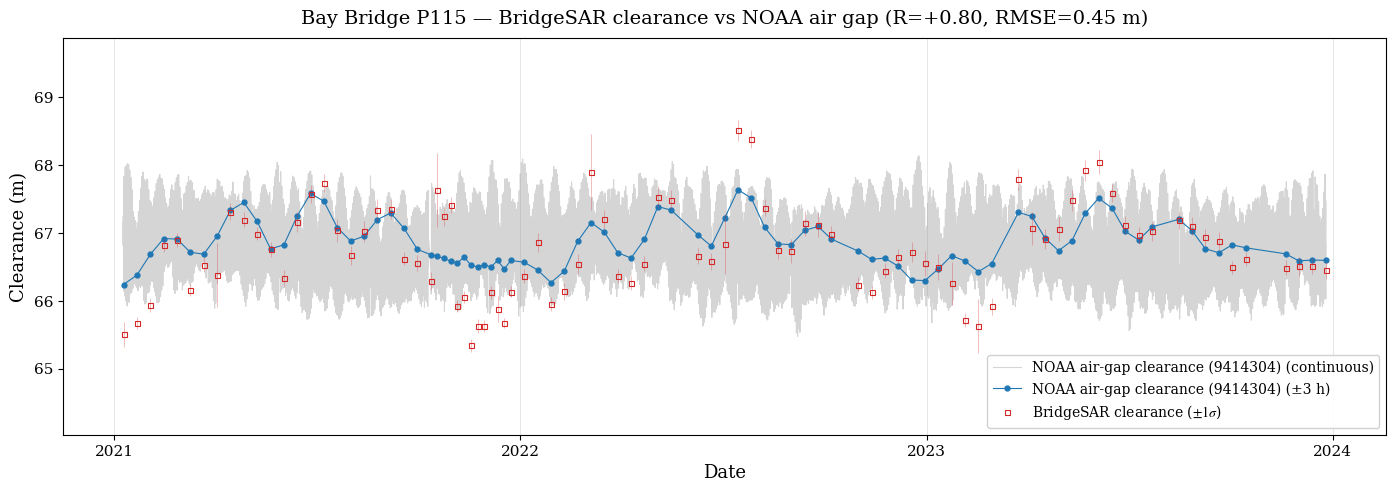

In [7]:
out_png = Path(cfg.out_dir) / f"clearance_timeseries_{cfg.track}.png"
out_png.parent.mkdir(parents=True, exist_ok=True)

show_nominal = None if cfg.airgap_station else cfg.deck_height_m

fig, ax = plot_clearance_timeseries(
    kept,
    ref_curve=ref["ref_curve"],          # continuous rolling-mean air-gap clearance
    ref_points=ref["ref_points"],        # acquisition-matched air-gap clearance
    deck_height_m=show_nominal,
    ref_label=f"NOAA air-gap clearance ({ref['station']})",
    title=f"{cfg.bridge_name} {cfg.track} — BridgeSAR clearance vs NOAA air gap "
          f"(R={ref['R']:+.2f}, RMSE={ref['RMSE_m']:.2f} m)",
    save_path=out_png,                   
)
print("saved", out_png)
fig